<a href="https://www.kaggle.com/code/cartelsmith/stacked-ensemble-model-mental-health-pred?scriptVersionId=336586032" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🎮 Gaming Addiction & Mental Health Risk: An Educational Walkthrough

Welcome! In this notebook, we're going to explore the relationship between gaming habits and mental health risk scores. Whether you're building out your data science portfolio or refining your machine learning pipelines, this dataset provides a fantastic sandbox. 

We will walk through:
1. **Exploratory Data Analysis (EDA)** to uncover trends and correlations.
2. **Data Cleaning & Feature Selection** to prep our data for modeling.
3. **Building an Ensemble Machine Learning Model** using Scikit-Learn to predict mental health risk.

Let's dive in and start coding!

## 1. Setup & Data Loading
First, let's load our necessary libraries and pull in the dataset. We'll be using `pandas` for data manipulation, `matplotlib` and `seaborn` for visualization, and `kagglehub` to directly download the dataset.

In [1]:
# Install dependencies if running locally:
# !pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
from sklearn import set_config
set_config(display='diagram')

# Set visualization styles
sns.set_theme(style='white', context='notebook')

# Prevent wrapping dataframes across multiple lines for better readability
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

# Set the path to the file you'd like to load
file_path = "gaming_addiction.csv"

# Load the latest version of the dataset
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ajitashwath/gaming-addiction-dataset",
  file_path,
)

## 2. Exploratory Data Analysis (EDA)
Before we build any models, we need to understand our data. Let's look at the first few rows and get a summary of the data types and potential missing values.

In [2]:
# Let's peek at the first 5 rows
display(df.head())

# Check data types and non-null counts
print(df.info())

# Store column names for later reference
column_names = df.columns.tolist()

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,rank_tier,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,weekend_playtime_hours,consecutive_hours_max,multiplayer_ratio,toxic_chat_reports,rage_quit_frequency,in_game_purchases,monthly_spending_usd,lootbox_openings,subscription_status,stress_score,loneliness_score,dopamine_dependency_index,self_control_score,impulsiveness_score,anxiety_level,depression_indicator,emotional_stability,sleep_hours,exercise_frequency_per_week,caffeine_intake_cups_day,social_interaction_hours,relationship_status,gpa_or_performance_score,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,Gold,3.5,4,1.0,4.9,6.5,0.67,0,0,0,38.67,10,NaN,8.2,8.8,2.7,7.0,5.1,9.9,8.5,3.7,6.3,2,0,2.7,In a relationship,4.0,4,0.0,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,Bronze,10.9,14,3.2,14.7,15.9,0.44,2,0,7,47.35,18,Premium,7.8,5.6,8.2,6.5,3.5,6.2,4.1,3.0,6.1,0,2,3.5,In a relationship,4.0,4,16.7,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,Master,8.6,7,2.4,11.6,13.1,0.32,0,1,3,37.80,4,Ultimate,8.4,4.1,5.0,4.2,6.1,7.7,6.7,3.3,6.1,1,3,2.0,Prefer not to say,4.0,6,8.5,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,Bronze,5.9,5,1.1,13.6,8.2,0.23,7,7,9,74.51,15,NaN,6.0,4.5,6.0,5.8,3.6,5.9,4.5,6.5,6.7,4,5,0.6,Married,4.0,3,8.7,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,Bronze,7.4,8,3.2,6.3,14.2,0.57,4,2,5,25.32,0,Premium,8.0,4.2,6.2,6.5,5.0,8.4,3.3,5.5,7.6,1,0,1.2,Single,2.6,3,21.9,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 49 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      250 non-null    object 
 1   age                          250 non-null    int64  
 2   gender                       250 non-null    object 
 3   country                      250 non-null    object 
 4   occupation                   250 non-null    object 
 5   income_level                 250 non-null    object 
 6   years_gaming                 250 non-null    int64  
 7   preferred_genre              250 non-null    object 
 8   platform                     250 non-null    object 
 9   device_type                  250 non-null    object 
 10  rank_tier                    250 non-null    object 
 11  daily_playtime_hours         250 non-null    float64
 12  weekly_play_sessions         250 non-null    int64  
 13  late_night_sessions_

### Visualizing Feature Correlations
Machine learning models thrive on strong signals. Let's find out which features have the strongest correlation with our target variable: `mental_health_risk_score`. 

We'll visualize this using a horizontal bar plot (Pareto style) and a grid of scatter plots.

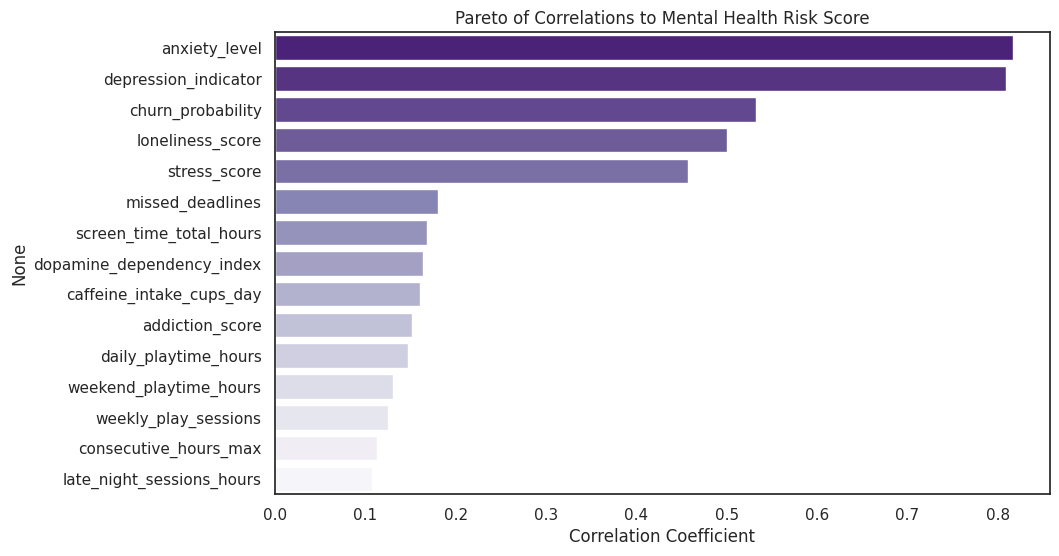

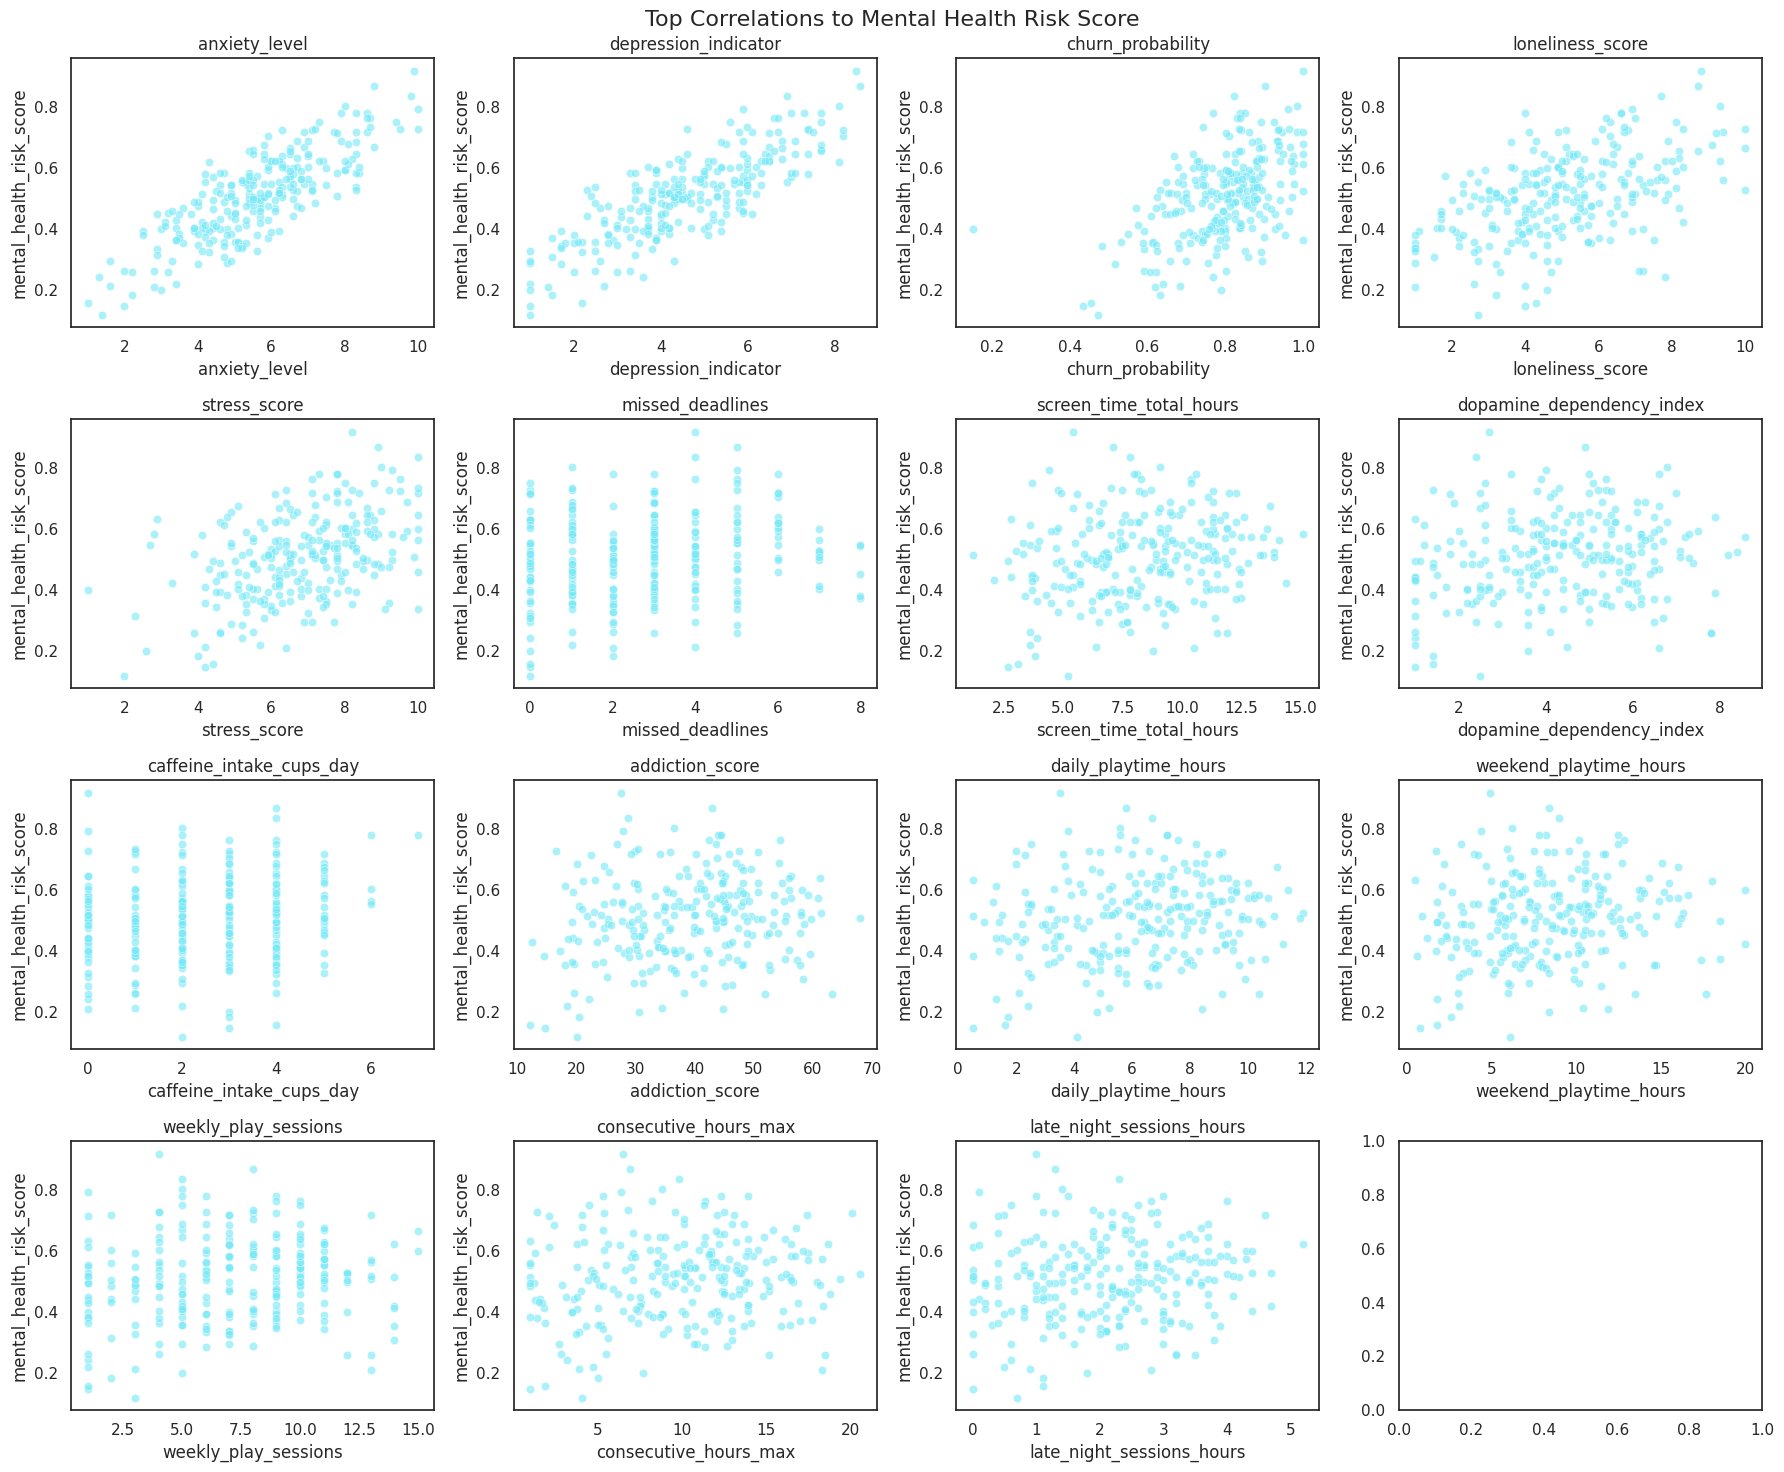

In [3]:
# Calculate numerical correlations
df_correlations = df.corr(numeric_only=True)

# Grab the top 15 features most strongly correlated with mental health risk
# (We take 16 and skip the 1st one, which is the target correlated with itself)
mh_health_risk_corrs = df_correlations['mental_health_risk_score'].nlargest(16)

# Plot the top correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=mh_health_risk_corrs[1:], y=mh_health_risk_corrs[1:].index, fill=True, orient='h', palette='Purples_r')
plt.title("Pareto of Correlations to Mental Health Risk Score")
plt.xlabel("Correlation Coefficient")
plt.show()

# Plotting scatter plots for the Top 15 parameters
fig, axes = plt.subplots(4, 4, figsize=(18, 15))
axes = axes.flatten()
mh_risk_cols = mh_health_risk_corrs.index.to_list()

for n, col in enumerate(mh_risk_cols[1:]): # Skip target variable itself
    sns.scatterplot(data=df, x=col, y='mental_health_risk_score', ax=axes[n], color='#73e8f7', alpha=0.6)
    axes[n].set_title(f'{col}')

plt.suptitle("Top Correlations to Mental Health Risk Score", fontsize=16)
plt.tight_layout()
plt.show()

## 3. Data Cleaning & Feature Selection
During EDA, we often find highly correlated features (multicollinearity). If two features provide the exact same information, keeping both just adds unnecessary noise to our model. 

For instance, `anxiety_level` and `depression_indicator` might be highly correlated. We can either feature-engineer a combined metric, or simply drop one. Here, we'll drop `depression_indicator`.

We'll also do a quick visual check to confirm we have no missing values.

Here are the features we are moving forward with: 
['mental_health_risk_score', 'anxiety_level', 'churn_probability', 'loneliness_score', 'stress_score', 'missed_deadlines', 'screen_time_total_hours', 'dopamine_dependency_index', 'caffeine_intake_cups_day', 'addiction_score', 'daily_playtime_hours', 'weekend_playtime_hours', 'weekly_play_sessions', 'consecutive_hours_max', 'late_night_sessions_hours']



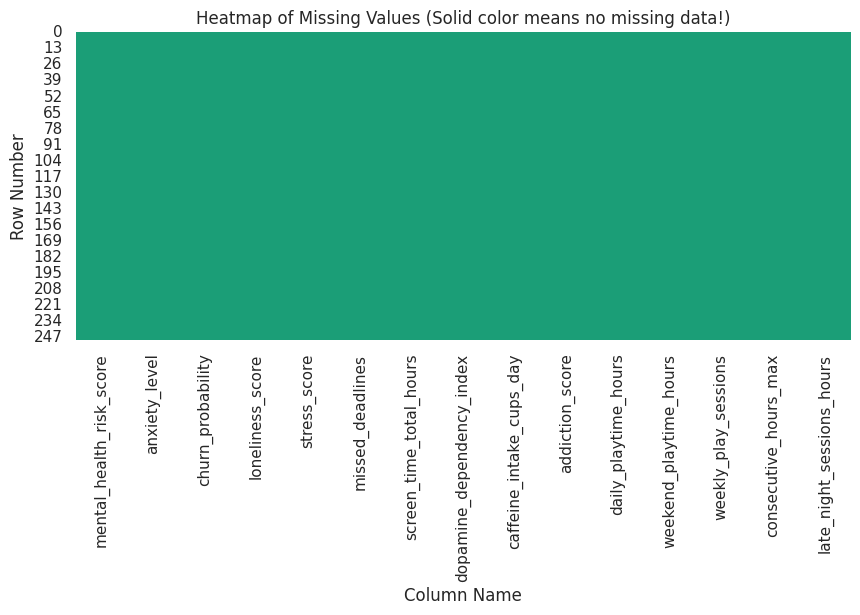

🙅🏽 Fantastic! There aren't any missing values in our feature set.


In [4]:
# Drop the redundant column
df_clean = df[mh_risk_cols].drop(columns=['depression_indicator'])

print(f'Here are the features we are moving forward with: \n{df_clean.columns.tolist()}\n')

# Visualize missing values using a heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df_clean.isna(), cmap='Dark2', cbar=False)
plt.ylabel('Row Number')
plt.xlabel('Column Name')
plt.title("Heatmap of Missing Values (Solid color means no missing data!)")
plt.show()

print("🙅🏽 Fantastic! There aren't any missing values in our feature set.")

## 4. Preparing for Machine Learning
Now, let's prepare to predict the `mental_health_risk_score`. 

We'll separate our data into **features (X)** and our **target (y)**. Then, we'll split the dataset into training and testing sets. Training data is used to teach our model, and testing data is held back to evaluate how well it learned.

Let's also visualize the distribution of our target variable.

Features shape: (250, 14)
Target shape: (250,)


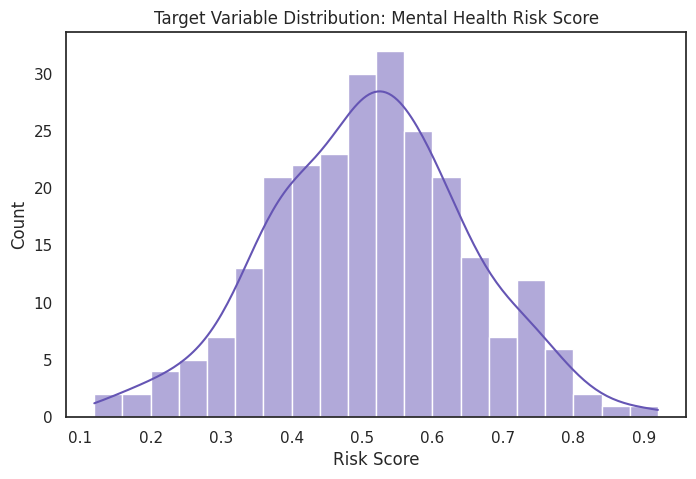

In [5]:
from sklearn.model_selection import train_test_split

# Separate features and target
features = df_clean.drop(columns=['mental_health_risk_score'])
target = df_clean['mental_health_risk_score']

print(f'Features shape: {features.shape}')
print(f'Target shape: {target.shape}')

# Visualize the target distribution
plt.figure(figsize=(8, 5))
sns.histplot(target, bins=20, color='#6555b4', kde=True)
plt.title("Target Variable Distribution: Mental Health Risk Score")
plt.xlabel("Risk Score")
plt.show()

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=12
)

## 5. Building a Stacking Regressor
Instead of relying on just one algorithm, we can combine several to create an **Ensemble Model**. 

We'll use a `StackingRegressor`. It trains several base models (like Decision Trees and Support Vector Machines) and then uses a "final estimator" (Linear Regression) to learn how to best combine their predictions. 

*Note: We also use `StandardScaler` in our pipeline to ensure all our features are on the same scale, which is crucial for algorithms like SVM and Ridge Regression.*

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import LinearSVR
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import StackingRegressor

# Define our base models
model_1 = DecisionTreeRegressor(random_state=42)
model_2 = LinearSVR(random_state=42)
model_3 = Ridge(random_state=42)
model_4 = LinearRegression()

# Combine them into a Stacking ensemble
ensemble_stack = StackingRegressor(
    estimators=[
        ('tree', model_1),
        ('svr', model_2),
        ('ridge', model_3),
        ('linreg', model_4)
    ],
    final_estimator=LinearRegression()
)

# Build a pipeline that scales data first, then feeds it to the stack
pipe = make_pipeline(StandardScaler(), ensemble_stack) 

# Train the model
pipe.fit(X_train, y_train)
print("✅ Model training complete!")
display(pipe)

✅ Model training complete!


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('stackingregressor',
                 StackingRegressor(estimators=[('tree',
                                                DecisionTreeRegressor(random_state=42)),
                                               ('svr',
                                                LinearSVR(random_state=42)),
                                               ('ridge',
                                                Ridge(random_state=42)),
                                               ('linreg', LinearRegression())],
                                   final_estimator=LinearRegression()))])

## 6. Model Evaluation
Let's see how our model performs on the unseen test data. We'll use the $R^2$ score, which tells us the proportion of the variance in the target variable that is predictable from the features. An $R^2$ of 1.0 is perfect.

In [7]:
# Evaluate on the test set
r2_score = pipe.score(X_test, y_test)

print(f'🎯 R^2 Score on Test Data: {r2_score:.3f}')

🎯 R^2 Score on Test Data: 0.729


## 7. Conclusion & Future Work
This notebook provides a solid baseline for modeling mental health risk scores based on gaming habits! But there is always room to iterate and improve. 

**Challenge yourself to fork this notebook and try:**
* **Cross-Validation:** Since this is a smaller dataset, try using k-fold cross-validation to get a more robust performance metric.
* **Alternative Ensembles:** Build a `VotingRegressor` and compare its performance to this Stacked model.
* **Advanced Algorithms:** Implement bagging or boosting regressors (like `RandomForest` or `XGBoost`) to see if they can beat our score.

*Click 'Copy & Edit' to get started. Happy Coding!*